In [1]:
# 1. Import main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns

from google.colab import drive

# 2. Mount Google Drive
drive.mount("/content/drive")

# 3. Navigate to the project working directory
%cd /content/drive/MyDrive/Mate_homework/final_project

Mounted at /content/drive
/content/drive/MyDrive/Mate_homework/final_project


# Data Overview

**Initial Data Structure Analysis**

At this stage, raw data is loaded and its integrity is verified. The main goal is to identify data types, missing values, and anomalies that will require correction.

*  ** The "events.csv" table:**

Order ID - order identifier

Order Date - order date

Ship Date - shipment date

Order Priority - order priority

Country Code - 3-letter country code

Product ID - product identifier

Sales Channel - sales channel (Online/Offline)

Units Sold - number of units sold

Unit Price - price per unit

Unit Cost - cost per unit


*  **The "products.csv" table:**

id - product identifier

item_type - product category


*   **The "countries.csv" table:**

name - country name

alpha-2 - 2-letter country code

alpha-3 - 3-letter country code

region - region

sub-region - subregion

**Common Columns for Table Joining**

To join the tables, we use Product ID from events and id from products to add product categories.

Next, we join Country Code from events with alpha-3 from countries to get geographic data for regional analysis.

### countries.csv

In [2]:
# Load countries reference table
countries = pd.read_csv("countries.csv")

# Preview first 5 rows
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [3]:
# Print dimensions (rows, columns)
print(f"Table dimensions: {countries.shape}")
print("-" * 30)

# General technical info: data types and missing values
countries.info()
print("-" * 30)

# Detailed data type check
print("Data types by column:")
print(countries.dtypes)

Table dimensions: (249, 5)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
------------------------------
Data types by column:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


**Overview of the countries table**

*   Table structure:

The table contains 249 records and 5 columns. All columns are recognized as object type (text), which is correct for country names and region codes.

*   Data quality:

The preliminary review via .info() showed that the countries table is almost complete, but there are isolated missing values (in the alpha-2, region, and sub-region columns) that will require attention at the next cleaning stage.











### products.csv

In [4]:
# Load products classifier
products = pd.read_csv("products.csv")

# Print technical characteristics
print(f"Table dimensions: {products.shape}")
print("-" * 30)

products.info()
print("-" * 30)

# View available categories
products.head()

Table dimensions: (12, 2)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
------------------------------


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


**Overview of the products table**

*  Table Structure:

The table contains 12 records and 2 columns. The id column is recognized as int64 (integer), item_type as object (string).

*   Data quality:

All 12 records are complete (non-null), which will facilitate joining with the main events table without losing category information.

### events.csv

In [5]:
# Load main dataset
events = pd.read_csv("events.csv")

# Preview transaction structure
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [6]:
# Check record count and column names
print(f"Table dimensions: {events.shape}")
print("-" * 30)

# General dataset information
events.info()
print("-" * 30)

# Check data types for conversion planning
print(events.dtypes)

Table dimensions: (1330, 10)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
------------------------------
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold      

**Overview of the events table**

*   Table structure:

The table contains 1,330 records and 10 columns. Dates (Order Date, Ship Date) are recognized as object (text). For analysis, they need to be converted to datetime format.

*   Data quality:

The Country Code column has 82 missing values (1,248 non-null out of 1,330). This is critical, as without them it is impossible to correctly join sales data with country names. There are also 2 missing values in Units Sold.

#Data cleaning

After the initial review, we move on to addressing technical issues. This is a critical step to ensure accuracy in subsequent data merging.

###countries.csv

For standardization, we convert column names to snake_case format, remove extra whitespace, and normalize text values.

In [7]:
# Normalize column names to snake_case standard
countries.columns = [col.lower().replace("-", "_").replace(" ", "_") for col in countries.columns]


# Strip invisible whitespace from all text columns
text_cols = countries.columns
countries[text_cols] = countries[text_cols].apply(lambda x: x.str.strip())

# Convert key geographic columns to lowercase
cols_to_lower = ['alpha_2', 'alpha_3', 'region', 'sub_region']
countries[cols_to_lower] = countries[cols_to_lower].apply(lambda x: x.str.lower())

Handling missing values and special cases.

Special attention is paid to restoring data that was incorrectly recognized as NaN.

In [8]:
# Count missing values per column
countries.isna().sum() / countries.shape[0] * 100 #for all 3 columns the share of missing values is 0.401606, exceeding 0.004%, so we cannot simply drop the missing values

# Display rows with missing data
missed_values=countries[countries.isnull().any(axis=1)]

# Restore Namibia code ('NA' is often incorrectly read as Not Available)
countries.loc[countries['name'] == 'Namibia', 'alpha_2'] = 'NA'

# Handle Antarctica data: fill regional affiliation with continent name
countries.loc[countries['name'] == 'Antarctica', ['region', 'sub_region']] = 'Antarctica'

# Final check for duplicates and missing values
print(f"Duplicate count: {countries.duplicated().sum()}")
print(f"Missing values after cleaning:\n{countries.isna().sum()}")

# Verify applied changes
countries.head()

Duplicate count: 0
Missing values after cleaning:
name          0
alpha_2       0
alpha_3       0
region        0
sub_region    0
dtype: int64


,name,alpha_2,alpha_3,region,sub_region
0,Afghanistan,af,afg,asia,southern asia
1,Åland Islands,ax,ala,europe,northern europe
2,Albania,al,alb,europe,southern europe
3,Algeria,dz,dza,africa,northern africa
4,American Samoa,as,asm,oceania,polynesia


**Cleaning results for countries:**

*   All headers and text codes have been normalized to a single case, eliminating the risk of implicit duplicates.
*   The Namibia code has been restored and specific data for Antarctica has been filled in.
*   The table contains no duplicates and is ready for consolidation with the main transaction dataset.

### products.csv

Cleaning the products reference table

This stage ensures normalization of product categories, which will prevent category duplication due to different letter case or extra whitespace during subsequent data grouping.

In [9]:
# General table structure before cleaning
products.info()
print("---"*20)

# Initial data preview
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
------------------------------------------------------------


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [10]:
# 1. Value normalization: convert to lowercase and remove invisible whitespace
products["item_type"] = products["item_type"].str.lower().str.strip()

# 2. Check for duplicates
# In the product classifier, each ID and name must be unique
prod_duplicate_rows = products.duplicated()
print(f"Detected duplicate count: {prod_duplicate_rows.sum()}")

# 3. Verify the applied changes
products.head()

Detected duplicate count: 0


,id,item_type
0,2103,cereal
1,7940,household
2,2455,clothes
3,1270,beverages
4,8681,office supplies


**Processing results for products:**

*   All categories have been converted to lowercase, which is critical for correct pivot table construction.
*   No duplicates were found (sum = 0), confirming the quality of the reference data.
*   The table is ready to be joined with the main events dataset using the product_id key.

### events.csv

In [11]:
# General table structure before cleaning
events.info()
print("---"*20)

# Initial data preview
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
------------------------------------------------------------


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [12]:
# 1. Normalize column headers
events.columns = [col.lower().replace("-", "_").replace(" ", "_") for col in events.columns]

# 2. Process text data (object type columns only)
text_cols = events.select_dtypes(include='object').columns
events[text_cols] = events[text_cols].apply(lambda x: x.str.strip().str.lower())

# 3. Convert dates to datetime format for time series analysis
events['order_date'] = pd.to_datetime(events['order_date'])
events['ship_date'] = pd.to_datetime(events['ship_date'])

events.head()

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


Handling Missing Values (NaN Analysis)

In [13]:
# Check percentage of missing values
missing_data = events.isna().sum() / events.shape[0] * 100
print(f"Missing value percentage:\n{missing_data}")

# Fill missing country codes with 'unknown' to preserve integrity during merge
events["country_code"] = events["country_code"].fillna("unknown")

# Fill missing units sold with median value
# Median is robust to outliers, preserving overall statistics without distortion
events["units_sold"] = events["units_sold"].fillna(events["units_sold"].median())


Missing value percentage:
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


After completing the transformations, we check for duplicates and remaining missing values.

In [14]:
# Check for transaction duplicates
print(f"Duplicate count: {events.duplicated().sum()}")

# Final check of types and non-null values
events.info()

Duplicate count: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


**Stage result:**

*   All missing values have been handled, no duplicates found.
*   The order_date and ship_date columns now have datetime64 type, enabling aggregation by time periods.
*   The table is ready to be joined with the countries and products reference tables.

In [15]:
# Get basic statistical characteristics for numerical metrics
# (count, mean, median, min, max, standard deviation)
events.describe()


,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873


1. **Numerical Data Analysis**


*   *Units Sold:*

Anomaly: minimum value — 2, maximum — 9,999.

Very wide range. In retail, 9,999 units in a single transaction looks like a wholesale purchase or data entry error. This may also reflect business specifics (B2B sales) or different sales channels (Online vs Offline).


*   *Unit Price and Unit Cost:*

Anomaly: minimum price — 9.33, maximum — 668.27. The mean (264.89) is significantly higher than the median (154.06). This indicates right-skewed distribution — many cheap items and a few very expensive ones pulling the average up. This is typical for stores with a wide assortment (from stationery to household appliances).


2. **Temporal Anomalies (Dates)**

*   *Ship Date vs Order Date*

Orders cover the period from 2010 to 2017.

# Data Analysis and Visualization

## Merging Tables

This stage consolidates data from three sources (events, products, countries) to create a unified analytical dataset.

**Key Operations:**
*   Joining: left join is used to preserve all sales transactions.
*   Cleaning: technical key duplicates removed and column names normalized.
*   Missing value handling: new missing values arising after the join are filled with "unknown" to preserve dataset integrity.








In [16]:
# Merge data: sales + product categories + geography
sales = events.merge(products, left_on='product_id', right_on='id', how='left') \
              .merge(countries, left_on='country_code', right_on='alpha_3', how='left')

# Remove technical columns that duplicate information
sales.drop(columns=['id', 'alpha_3', 'alpha_2'], inplace=True)

# Rename 'name' to 'country_name' to avoid confusion
sales.rename(columns={'name': 'country_name'}, inplace=True)

# Fill geographic missing values that appeared after the merge
geo_cols = ['country_name', 'region', 'sub_region']
sales[geo_cols] = sales[geo_cols].fillna("unknown")

# Final check: data types and absence of missing values
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  item_type       1330 non-null   object        
 11  country_name    1330 non-null   object        
 12  region          1330 non-null   object        
 13  sub_region      1330 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

In [17]:
sales.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,cereal,Norway,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,cereal,Serbia,europe,southern europe
2,101025998,2014-07-18,2014-08-11,m,unknown,7940,online,4693.0,668.27,502.54,household,unknown,unknown,unknown
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,clothes,Montenegro,europe,southern europe
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,beverages,Serbia,europe,southern europe


A complete dataset of 14 columns and 1,330 records has been created. The data is ready for business metric calculation and visualization. All text features have been converted to lowercase, ensuring no duplicates during grouping.

## General Metrics

We now transform the tables into meaningful numbers and charts. Let's start with the company's main KPIs to get the overall business picture.

### 1. Profitability and Logistics Calculation

We create new metrics: financial (Revenue, Profit) and operational (Order Processing).

In [18]:
# Financial calculations
sales["revenue"] = sales["units_sold"] * sales["unit_price"]
sales["total_cost"] = sales["units_sold"] * sales["unit_cost"]
sales["profit"] = sales["revenue"] - sales["total_cost"]

# Logistics calculations
# Calculate the difference between order and shipment dates
sales["order_processing"] = (sales["ship_date"] - sales["order_date"]).dt.days

# Preview the updated dataset
sales.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region,revenue,total_cost,profit,order_processing
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,cereal,Norway,europe,northern europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,cereal,Serbia,europe,southern europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,m,unknown,7940,online,4693.0,668.27,502.54,household,unknown,unknown,unknown,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,clothes,Montenegro,europe,southern europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,beverages,Serbia,europe,southern europe,362897.60,243129.92,119767.68,38


### 2. Key Performance Indicators (Executive Summary)

These numbers provide a quick answer to: "How did the reporting period go?".

In [19]:
# Aggregate key metrics
orders_cnt = sales["order_id"].count()
total_revenue = sales["revenue"].sum()
total_profit = sales["profit"].sum()
total_countries = sales["country_code"].nunique()
avg_delivery = sales["order_processing"].mean()

print(f"{'-'*40}")
print(f"KEY METRICS:")
print(f"{'-'*40}")
print(f"Total orders:         {orders_cnt:,}")
print(f"Total revenue:        ${total_revenue:,.2f}")
print(f"Total profit:         ${total_profit:,.2f}")
print(f"Countries covered:    {total_countries}")
print(f"Avg. delivery time:   {avg_delivery:.1f} days")
print(f"{'-'*40}")

----------------------------------------
KEY METRICS:
----------------------------------------
Total orders:         1,330
Total revenue:        $1,704,628,370.65
Total profit:         $501,842,633.12
Countries covered:    46
Avg. delivery time:   24.8 days
----------------------------------------


### 3. Sales Structure (Regions and Products)

We analyze category popularity and market activity.

In [20]:
# Statistics by region and product
region_stats = sales["region"].value_counts()
popular_products = sales["item_type"].value_counts()

print(f"ORDER COUNT BY REGION:\n{region_stats}\n")
print(f"{'-'*40}")
print(f"TOP-5 CATEGORIES BY COUNT:\n{popular_products.head(5)}")

ORDER COUNT BY REGION:
region
europe     1166
unknown      82
asia         82
Name: count, dtype: int64

----------------------------------------
TOP-5 CATEGORIES BY COUNT:
item_type
office supplies    123
beverages          121
personal care      115
cosmetics          114
vegetables         114
Name: count, dtype: int64


## Sales Structure and Product Popularity Analysis

In this section, we examine the company's financial results.

The main goal is to identify the most profitable categories, regions, and sales channels.

### 1. Analysis by Product Category (Item Type)

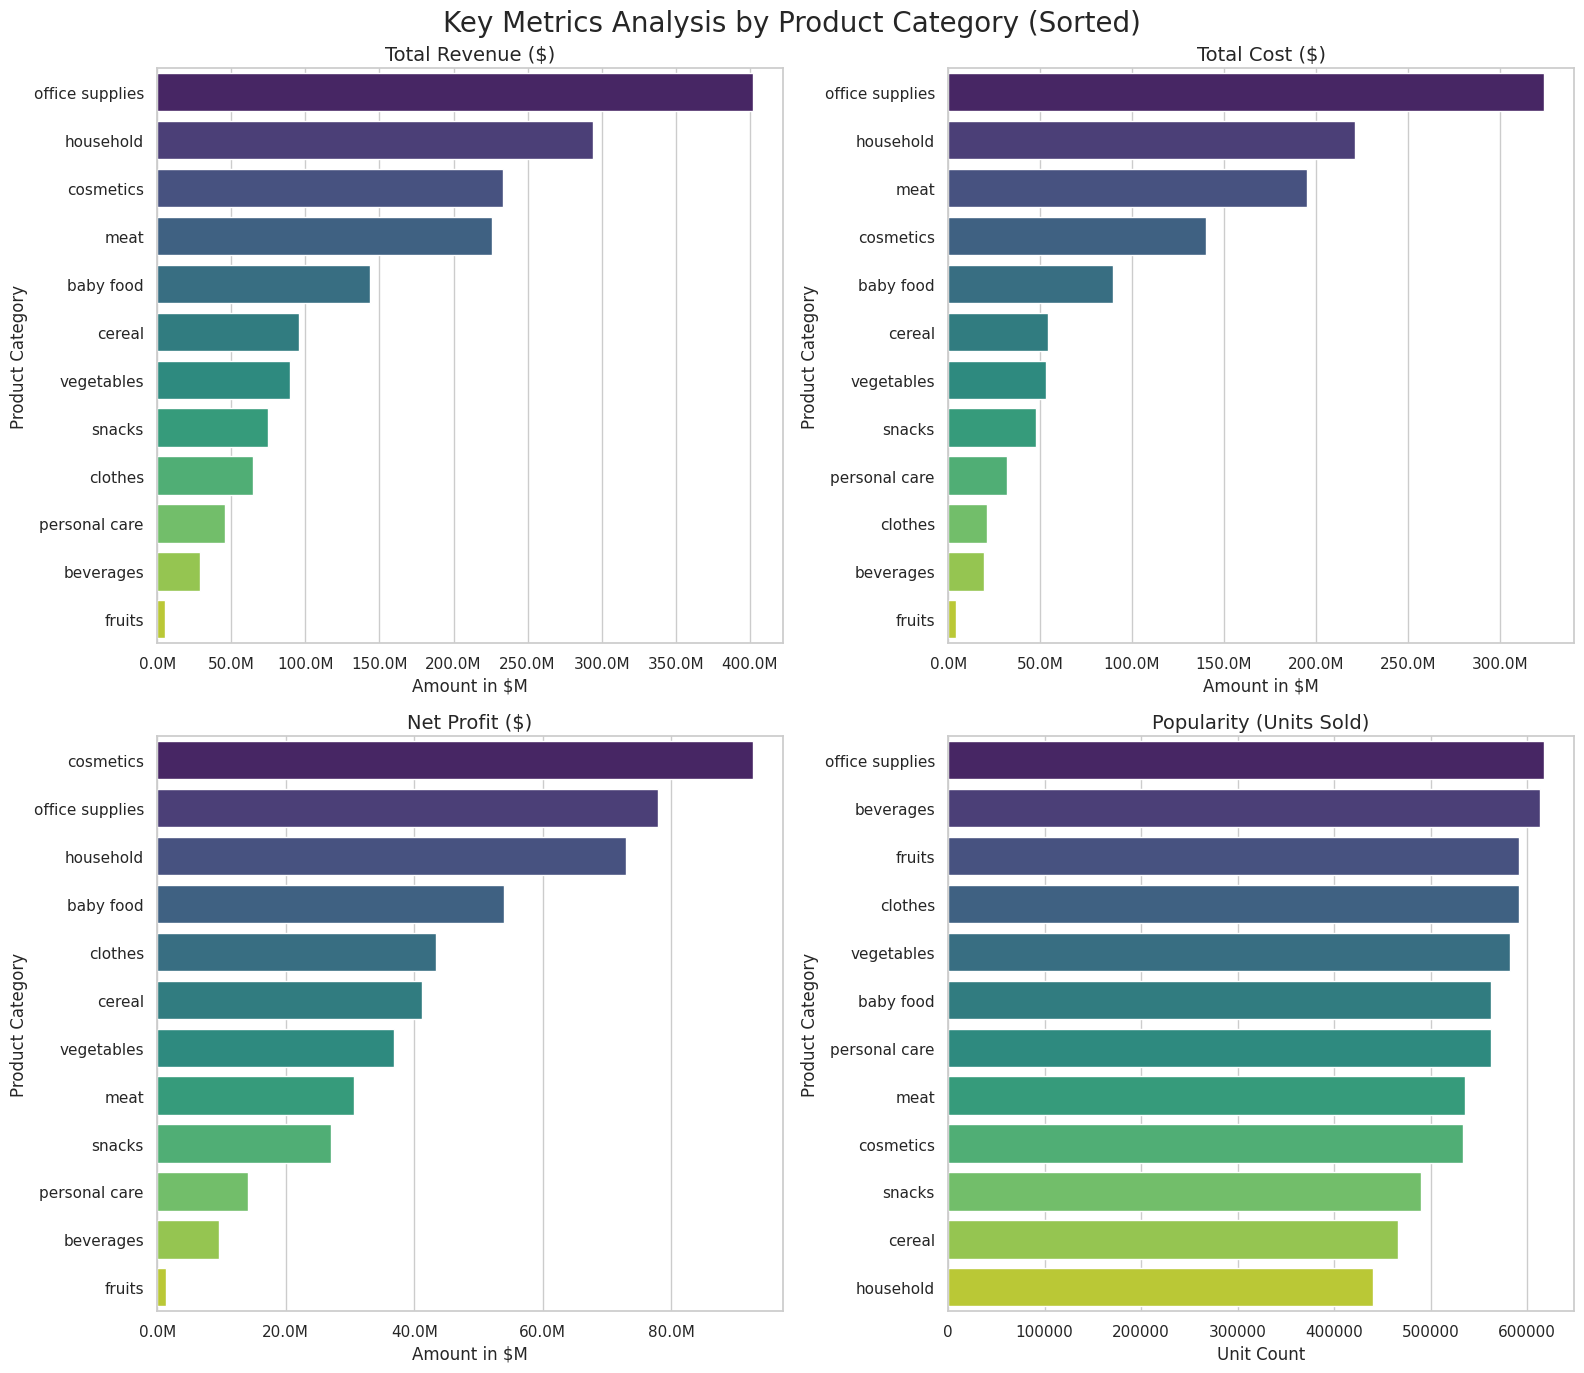

In [21]:
# Group data by category
cat_analysis = sales.groupby('item_type')[['revenue', 'total_cost', 'profit', 'units_sold']].sum().sort_values(by='profit', ascending=False).reset_index()

# Set style and create 2x2 grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Key Metrics Analysis by Product Category (Sorted)', fontsize=20)

# Function to format financial axes in millions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# 1. Revenue — sorted by revenue
rev_data = cat_analysis.sort_values('revenue', ascending=False)
sns.barplot(ax=axes[0, 0], data=rev_data, x='revenue', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[0, 0].set_title('Total Revenue ($)', fontsize=14)
axes[0, 0].xaxis.set_major_formatter(formatter)
axes[0, 0].set_xlabel('Amount in $M')
axes[0, 0].set_ylabel('Product Category')

# 2. Total Cost — sorted by cost
cost_data = cat_analysis.sort_values('total_cost', ascending=False)
sns.barplot(ax=axes[0, 1], data=cost_data, x='total_cost', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[0, 1].set_title('Total Cost ($)', fontsize=14)
axes[0, 1].xaxis.set_major_formatter(formatter)
axes[0, 1].set_xlabel('Amount in $M')
axes[0, 1].set_ylabel('Product Category')

# 3. Profit — sorted by profit
profit_data = cat_analysis.sort_values('profit', ascending=False)
sns.barplot(ax=axes[1, 0], data=profit_data, x='profit', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[1, 0].set_title('Net Profit ($)', fontsize=14)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].set_xlabel('Amount in $M')
axes[1, 0].set_ylabel('Product Category')

# 4. Popularity (Units Sold) — sorted by units
units_data = cat_analysis.sort_values('units_sold', ascending=False)
sns.barplot(ax=axes[1, 1], data=units_data, x='units_sold', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[1, 1].set_title('Popularity (Units Sold)', fontsize=14)
axes[1, 1].set_xlabel('Unit Count')
axes[1, 1].set_ylabel('Product Category')

plt.tight_layout()
plt.show()

**Conclusions on Product Categories**


*   Most profitable product — Cosmetics.
Despite low sales volume (9th place), the category leads in net profit ($90M+), indicating high margins.

*   Revenue driver — Office Supplies.
Generates the highest revenue ($400M+) and the most orders, but ranks only 2nd in profit due to significant costs.

*   Efficiency leader — Household.
Shows high profit with minimal units sold — this is the product with the highest average order value.

*   Low margin — Beverages and Fruits.
Despite high popularity, they generate the least net profit. These are mass-market goods that are not the primary source of earnings.

The business should focus on marketing cosmetics and household goods, as they generate maximum revenue with minimal operational effort.

### 2. Geographic Sales Analysis

In this section, we examine the distribution of financial metrics by region and country. This will help identify priority markets and areas with the highest margins.

#### 2.1. Analysis by Regions

We compare revenue and profit for each region and visualize profit share in a pie chart.

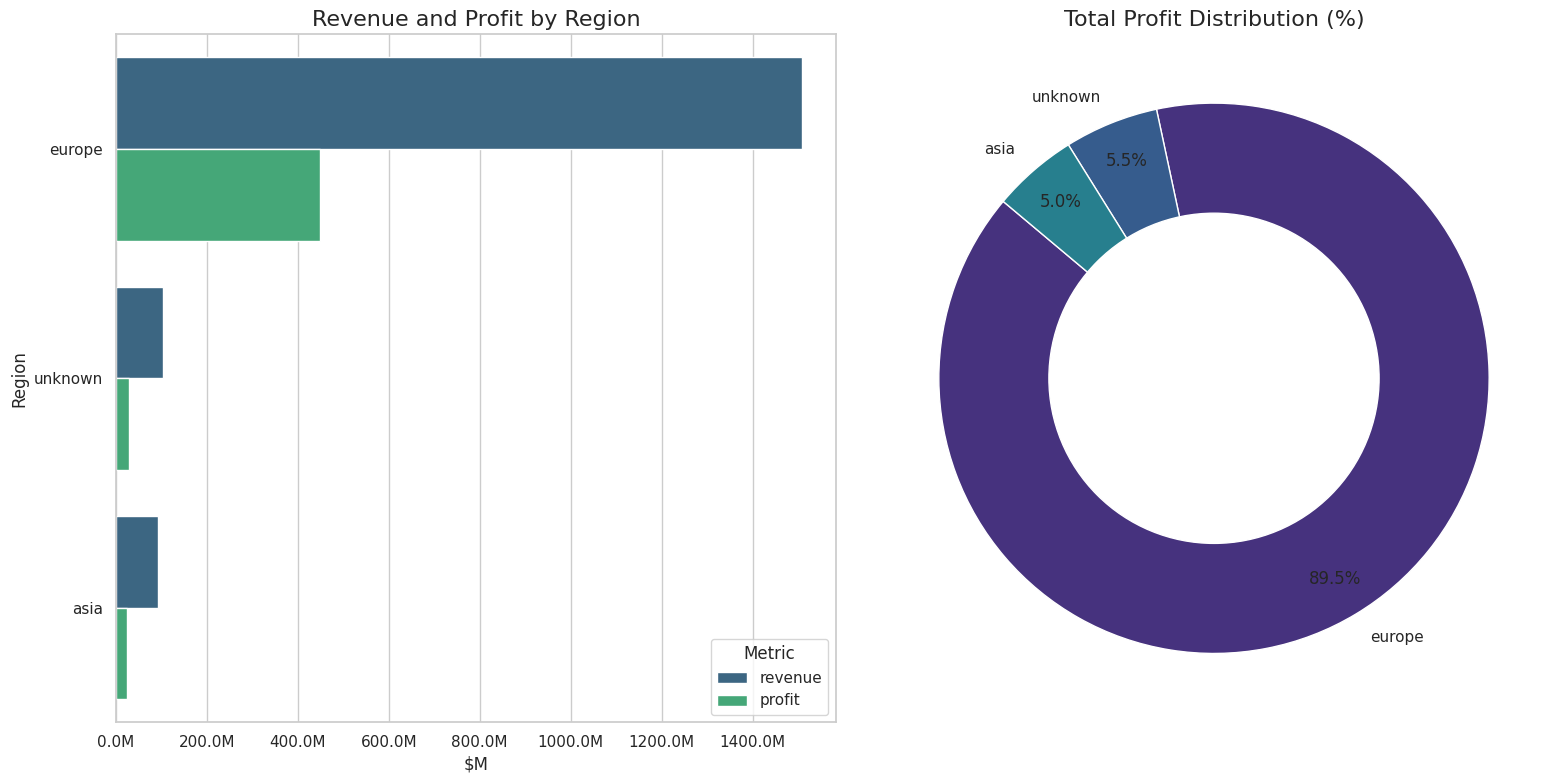

In [22]:
# Set style and create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# Prepare regional data (sorted by profit)
region_data = sales.groupby('region')[['revenue', 'total_cost', 'profit', 'units_sold']].sum().sort_values('profit', ascending=False).reset_index()

# Revenue vs. Profit chart by region
region_melted = region_data.melt(id_vars='region', value_vars=['revenue', 'profit'], var_name='Metric', value_name='Amount')
sns.barplot(ax=axes[0], data=region_melted, x='Amount', y='region', hue='Metric', palette='viridis')
axes[0].set_title('Revenue and Profit by Region', fontsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_xlabel('$M')
axes[0].set_ylabel('Region')

# Pie chart of profit share
axes[1].pie(region_data['profit'], labels=region_data['region'], autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('viridis'), pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.60, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Total Profit Distribution (%)', fontsize=16)

plt.tight_layout()
plt.show()

**Conclusion:**


*  European dominance: the "europe" region is the absolute leader across all metrics. It accounts for nearly 90% of the total profit.

* High profitability: revenue in the European region exceeds $1,400M, while profit is approximately $450M, indicating high margins compared to other markets.

*   Other regions: the contribution of Asia and unknown regions is minimal — together they generate only 10.5% of profit. "Unknown" generates slightly more (5.5%) than Asia (5.0%), despite similar revenue volumes.

The business is critically dependent on the European market, which is the primary source of both revenue and net profit.


#### 2.2. TOP-10 Countries by Key Metrics
Let's take a look at the top countries by profit and product popularity (number of sales).

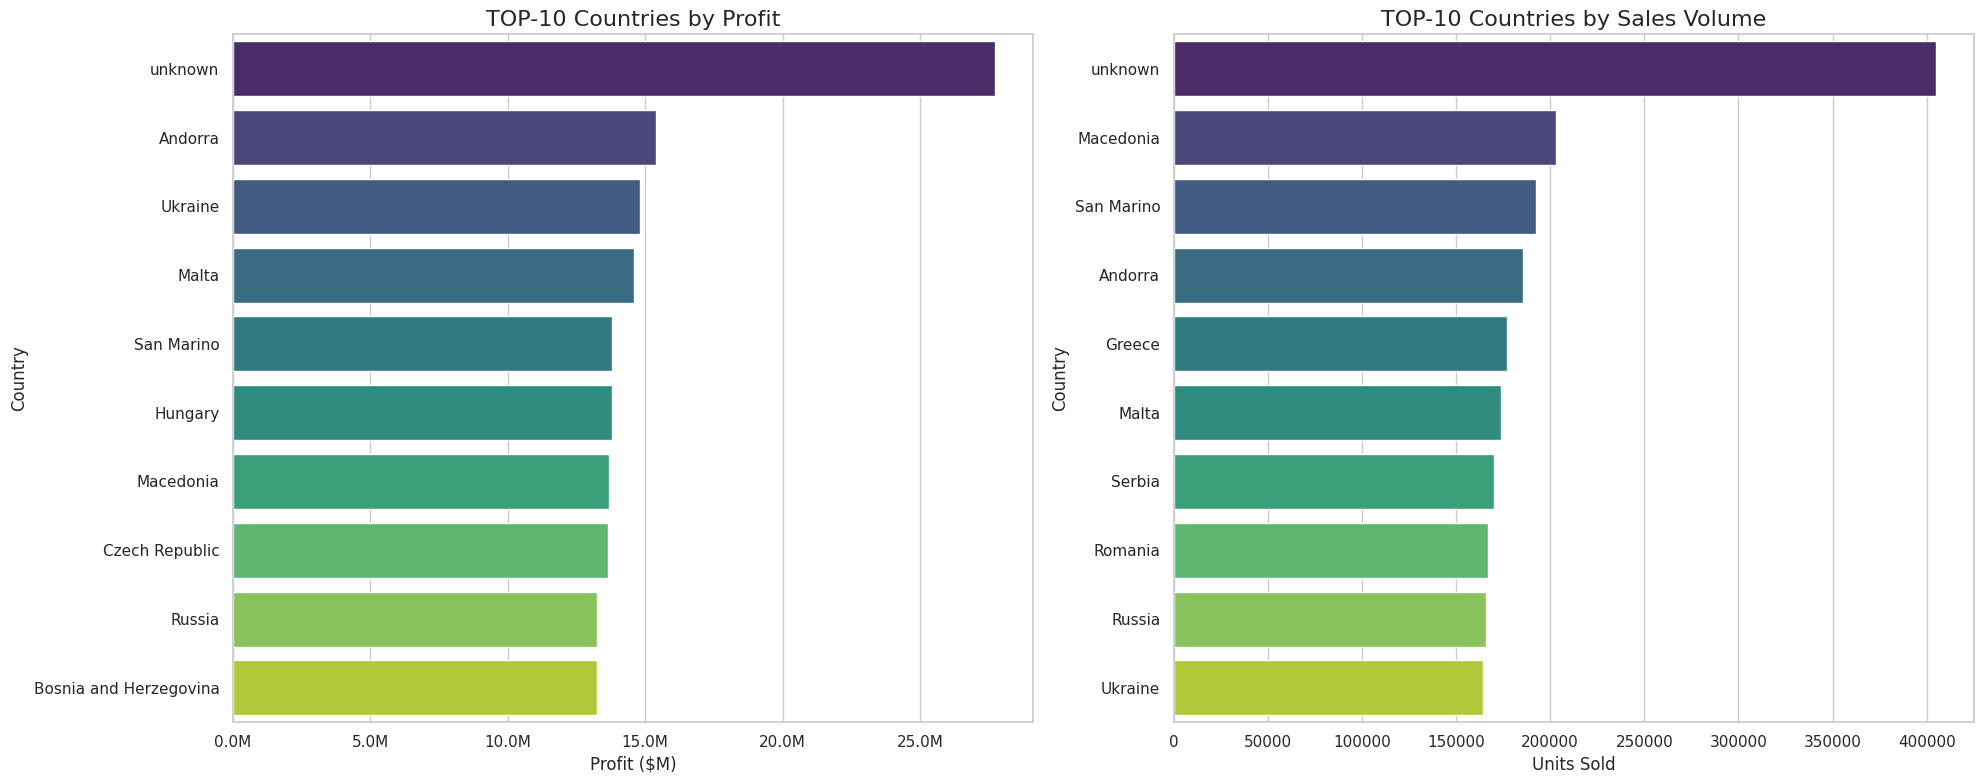

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# TOP-10 countries by profit
top_profit_countries = sales.groupby('country_name')['profit'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[0], data=top_profit_countries, x='profit', y='country_name', hue='country_name', palette='viridis', legend=False)
axes[0].set_title('TOP-10 Countries by Profit', fontsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_xlabel('Profit ($M)')
axes[0].set_ylabel('Country')

# TOP-10 countries by popularity (units sold)
top_units_countries = sales.groupby('country_name')['units_sold'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[1], data=top_units_countries, x='units_sold', y='country_name', hue='country_name', palette='viridis', legend=False)
axes[1].set_title('TOP-10 Countries by Sales Volume', fontsize=16)
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

**Conclusion:**

*  Dominance of unidentified data: the "unknown" category leads by a wide margin, generating nearly $28M in profit and over 400K sales. This indicates a significant volume of transactions where the country was not identified.

*   Ukraine's margin leadership: Ukraine ranks in the TOP-3 by profit (approximately $15M), despite being only 10th by sales volume. This indicates the highest profit per unit among all countries presented.

*   Volume vs. profit: Macedonia and San Marino show high sales volumes (2nd and 3rd places), but in terms of net profit they lag behind Andorra and Ukraine.

*   Stability of other markets: the remaining countries (Malta, Hungary, Czech Republic, Russia) show relatively even results with profit in the $13–15M range.


The key profit driver is the European sector, where the Ukrainian market stands out for its high sales efficiency.

### 3. Sales Channel Analysis
We will compare channels across four key metrics: revenue, costs, net profit, and number of orders.

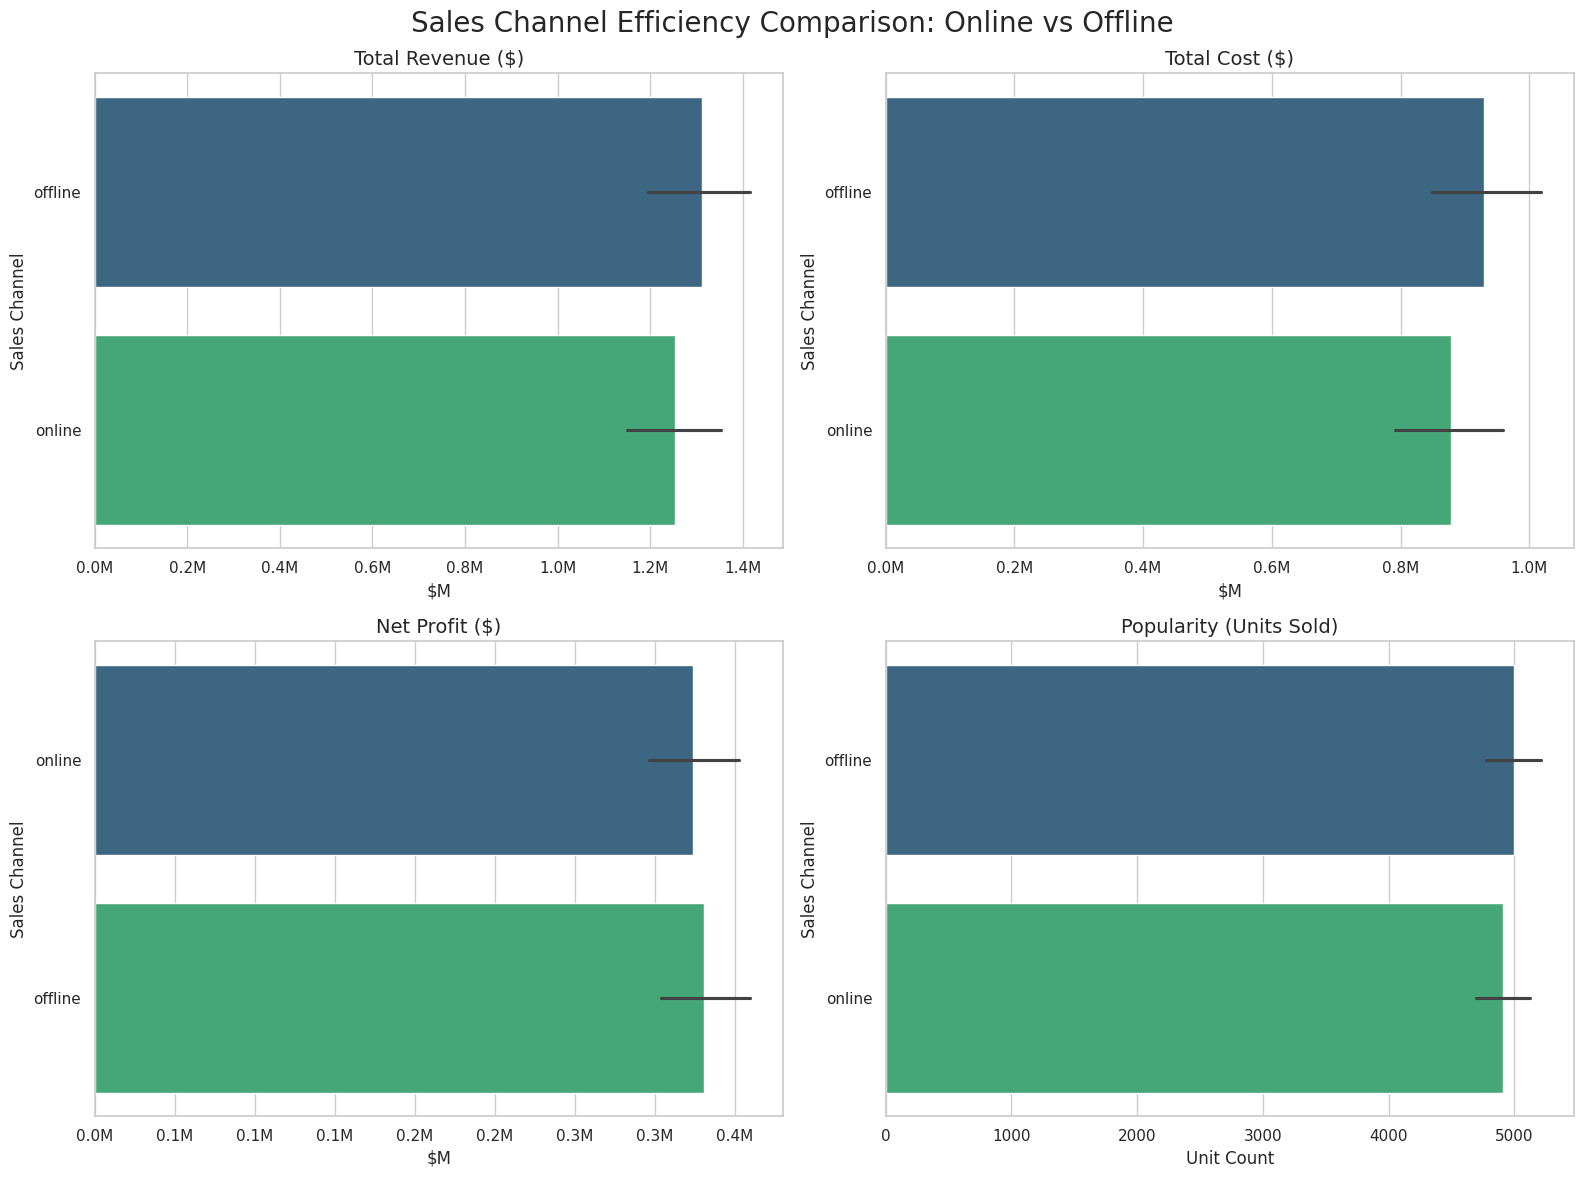

In [24]:
# Set style and create 2x2 grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Channel Efficiency Comparison: Online vs Offline', fontsize=20)

# Форматер для мільйонів
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# 1. Revenue
sns.barplot(ax=axes[0, 0], data=sales.sort_values('revenue', ascending=False),
            x='revenue', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[0, 0].set_title('Total Revenue ($)', fontsize=14)
axes[0, 0].xaxis.set_major_formatter(formatter)
axes[0, 0].set_xlabel('$M')
axes[0, 0].set_ylabel('Sales Channel')

# 2. Total Cost
sns.barplot(ax=axes[0, 1], data=sales.sort_values('total_cost', ascending=False),
            x='total_cost', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[0, 1].set_title('Total Cost ($)', fontsize=14)
axes[0, 1].xaxis.set_major_formatter(formatter)
axes[0, 1].set_xlabel('$M')
axes[0, 1].set_ylabel('Sales Channel')

# 3. Profit
sns.barplot(ax=axes[1, 0], data=sales.sort_values('profit', ascending=False),
            x='profit', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[1, 0].set_title('Net Profit ($)', fontsize=14)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].set_xlabel('$M')
axes[1, 0].set_ylabel('Sales Channel')

# 4. Popularity (Units Sold)
sns.barplot(ax=axes[1, 1], data=sales.sort_values('units_sold', ascending=False),
            x='units_sold', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[1, 1].set_title('Popularity (Units Sold)', fontsize=14)
axes[1, 1].set_xlabel('Unit Count')
axes[1, 1].set_ylabel('Sales Channel')

plt.tight_layout()
plt.show()

**Conclusion:**

*   Offline leads across all metrics: revenue, profit, and sales volume. It is the core foundation of the business.

*   Despite higher costs (approximately $0.9M), offline generates higher net profit ($0.35M+), demonstrating its high efficiency.

*   Offline has higher sales intensity (>4,500 units), though the online channel is close (4,400 units).

*   The minimal gap between channels indicates that the business successfully diversifies its risks.

Offline currently generates the main revenue, but online has scaling potential if logistics costs are optimized.

## Profit vs. Shipping Speed Analysis

In this section, we will test the hypothesis: does the duration of logistics processes affect the financial outcome of an order

In [25]:
# Calculate average profit for each shipping duration
profit_by_days = sales.groupby('order_processing')['profit'].mean().reset_index()

# Calculate Pearson correlation
correlation = sales['order_processing'].corr(sales['profit'])
print(f"Correlation between shipping time and profit: {correlation:.4f}")

Correlation between shipping time and profit: 0.0607


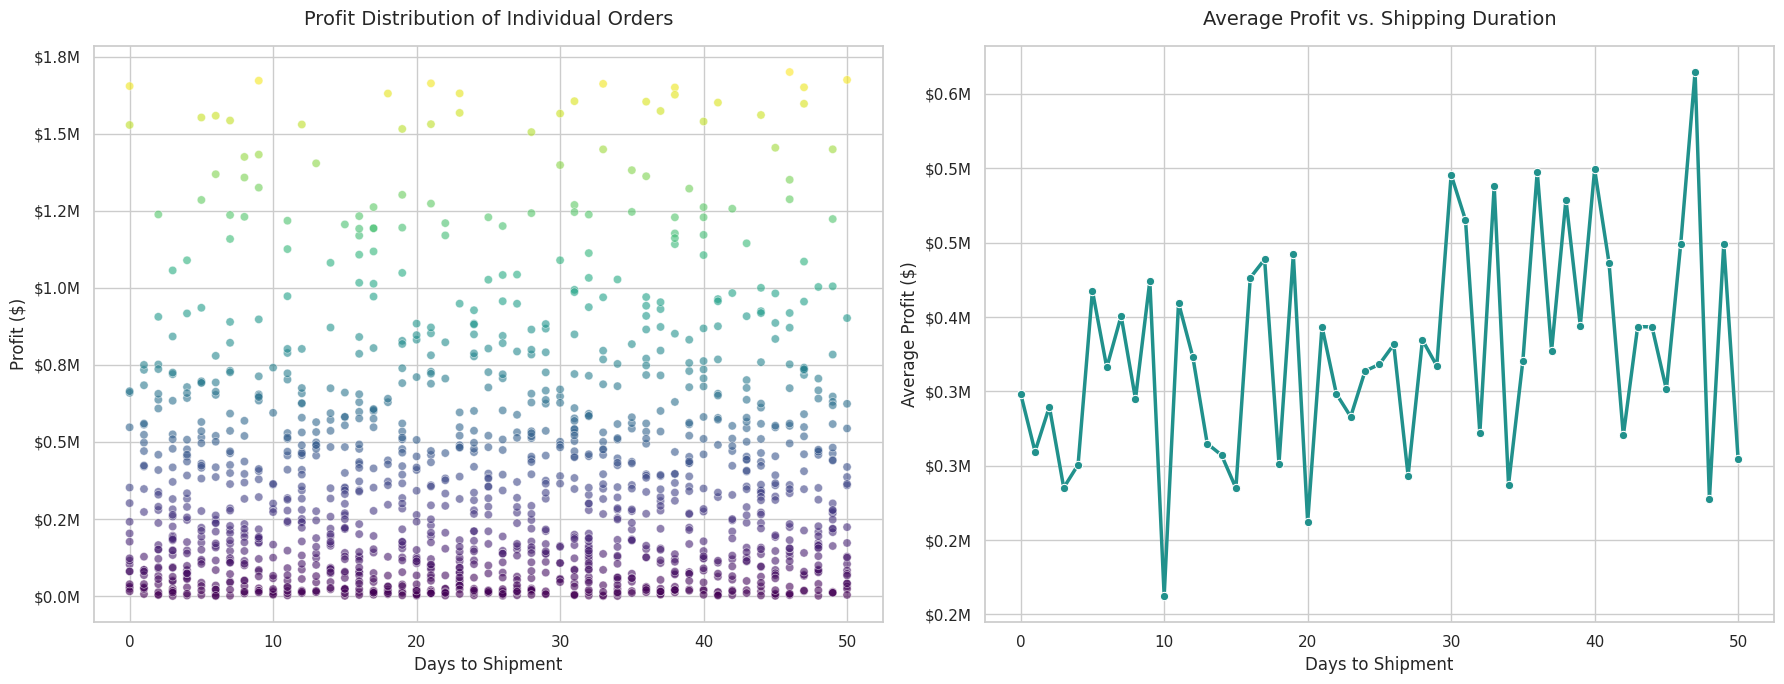

In [26]:
# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Formatter for y-axis
million_formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

# Scatter Plot
sns.scatterplot(ax=axes[0], data=sales, x='order_processing', y='profit',
                hue='profit', palette='viridis', alpha=0.6, legend=False)
axes[0].set_title('Profit Distribution of Individual Orders', fontsize=14, pad=15)
axes[0].set_xlabel('Days to Shipment')
axes[0].set_ylabel('Profit ($)')
axes[0].yaxis.set_major_formatter(million_formatter)

# Line Plot
sns.lineplot(ax=axes[1], data=profit_by_days, x='order_processing', y='profit',
             marker='o', color='#21918c', linewidth=2.5)
axes[1].set_title('Average Profit vs. Shipping Duration', fontsize=14, pad=15)
axes[1].set_xlabel('Days to Shipment')
axes[1].set_ylabel('Average Profit ($)')
axes[1].yaxis.set_major_formatter(million_formatter)

plt.tight_layout()
plt.show()

**Impact of Shipping Time on Profitability**

The analysis demonstrated that shipping speed has no direct impact on the financial outcome of orders.

*   The Pearson correlation coefficient is approximately 0.06. This critically low value mathematically confirms the absence of a relationship between waiting time and profit amount.

*   On the scatter plot, orders with high profit (over $1.5M) occur both on day 1 and day 50 of waiting. There is no tendency for profit to decrease with longer processing.

*   The average profit trend chart shows significant fluctuations, but they are chaotic in nature and show no clear upward or downward trend.

Since profit is not affected by delays, the business can focus on service quality. Although speed does not directly generate more revenue, it affects customer satisfaction and repeat purchase likelihood. A logistics window of up to 50 days is safe for the current financial model.

## Sales Dynamics Over Time (Time Series Analysis)


In this section, we conduct a comprehensive time series analysis to track the evolution of company revenue. The analysis covers three levels of detail: geographic regions, key partner countries, and product categories. This approach identifies hidden seasonality, large contract periodicity, and profit drivers shaping financial results across different years.

### 1. Sales Dynamics in Key Regions (Time Series)


This section focuses on a detailed examination of how sales volumes and revenue changed month to month in the two largest regions: Asia and Europe. This will reveal seasonal peaks, anomalies, and the overall business development trend.

In [27]:
# Convert dates and create month column
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales['month_year'] = sales['order_date'].dt.to_period('M').astype(str)

# Calculate revenue if not present
if 'revenue' not in sales.columns:
    sales['revenue'] = sales['units_sold'] * sales['unit_price']

# Group data once for the entire analysis
monthly_sales = sales.groupby(['month_year', 'region']).agg({'units_sold': 'sum', 'revenue': 'sum'}).reset_index()


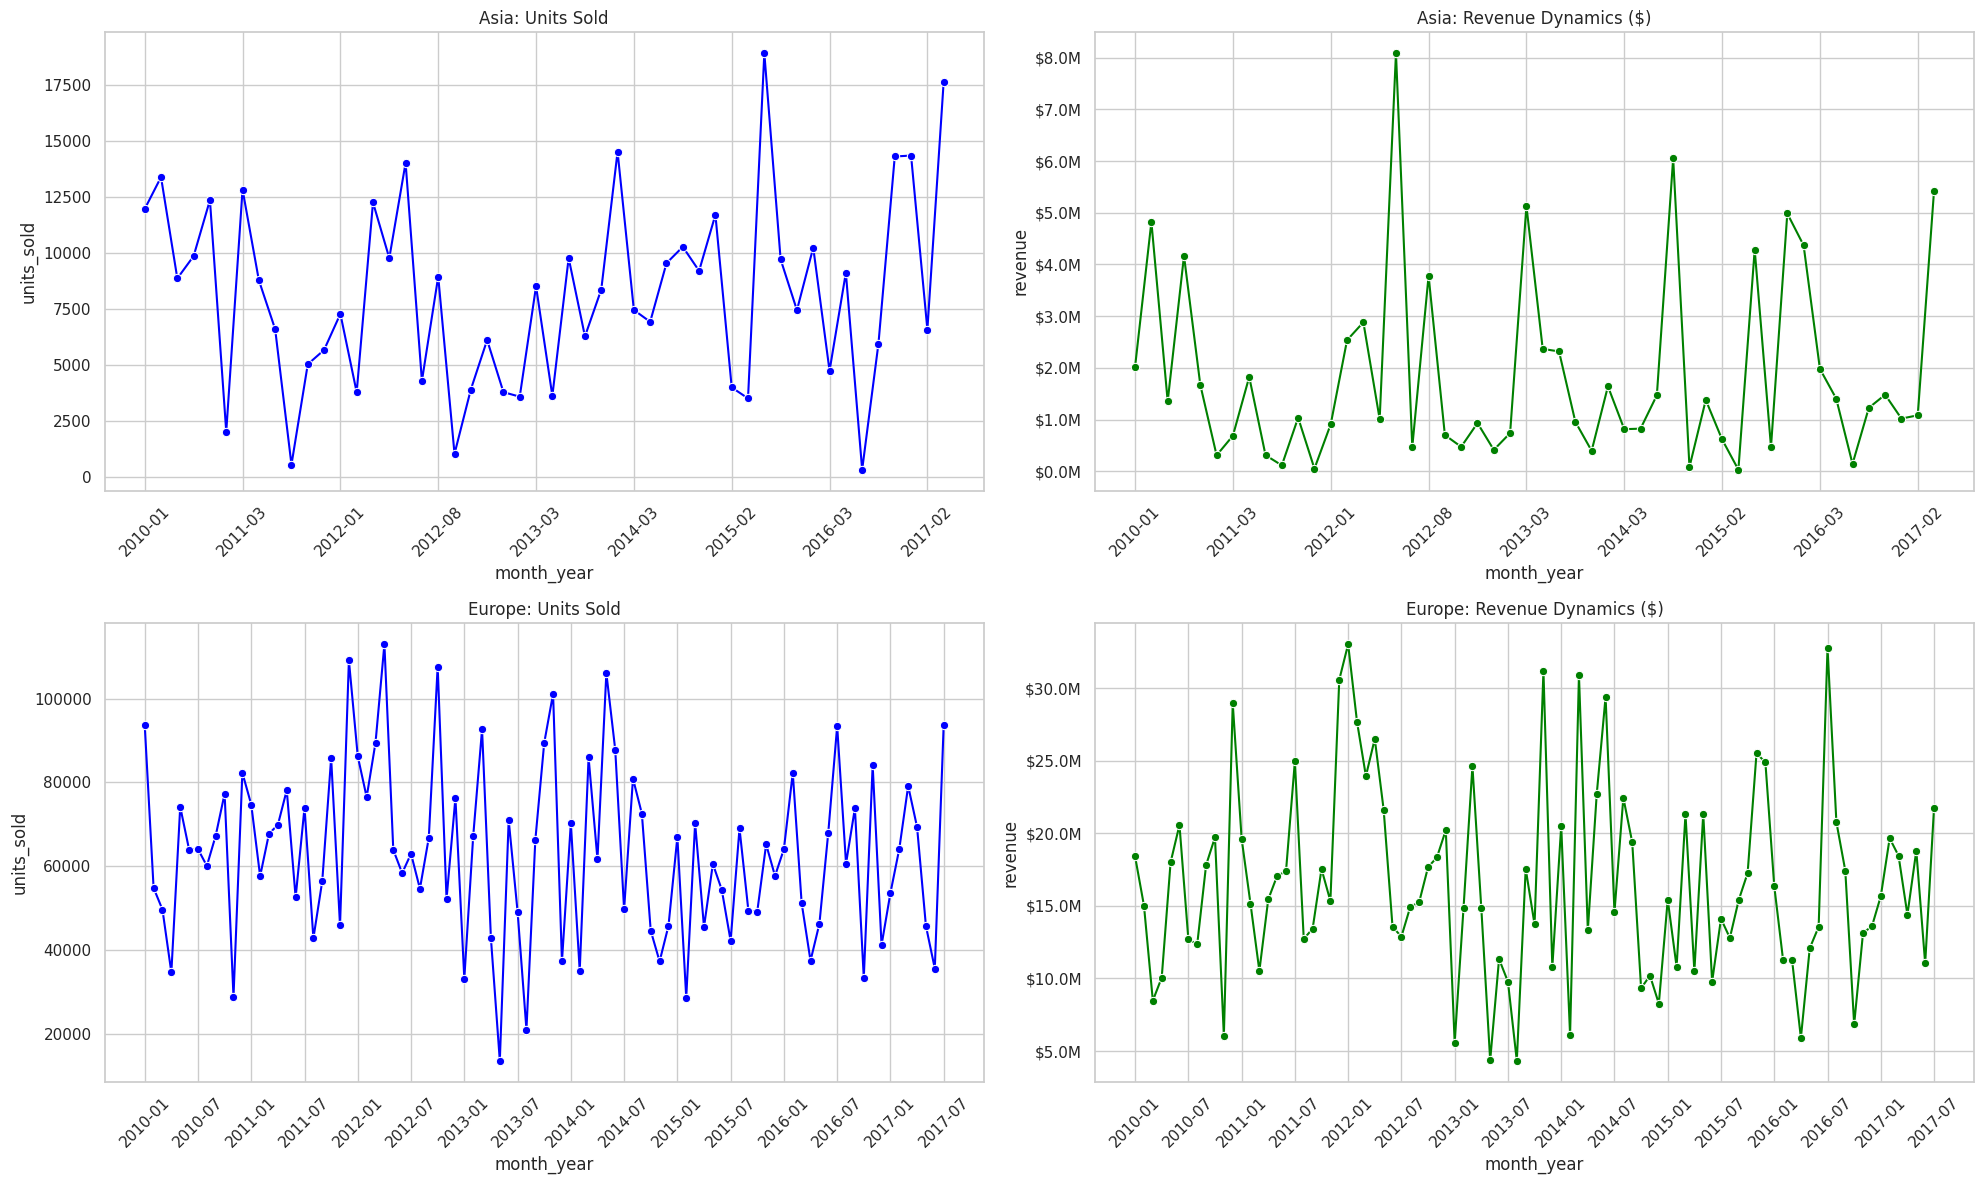

In [28]:
# Set general style
plt.figure(figsize=(20, 12))
sns.set_theme(style="whitegrid")

# Formatter for converting numbers to millions of dollars
# x/1e6 divides by million, .1f keeps one decimal place
money_formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

# Get sorted unique list of all months
all_months = sorted(monthly_sales['month_year'].unique())

# Helper function to avoid repeating x-axis code
def fix_x_axis(ax):
    # Show every 6th label (once per half year) to avoid clutter
    ax.xaxis.set_major_locator(ticker.IndexLocator(base=6, offset=0))
    ax.tick_params(axis='x', rotation=45)

# --- ASIA ---
# 1. Volume (Asia)
ax1 = plt.subplot(2, 2, 1)
asia_data = monthly_sales[monthly_sales['region'] == 'asia']
sns.lineplot(data=asia_data, x='month_year', y='units_sold', marker='o', color='blue')
plt.title('Asia: Units Sold')
fix_x_axis(ax1)

# 2. Revenue (Asia)
ax2 = plt.subplot(2, 2, 2)
sns.lineplot(data=asia_data, x='month_year', y='revenue', marker='o', color='green')
plt.title('Asia: Revenue Dynamics ($)')
ax2.yaxis.set_major_formatter(money_formatter)
fix_x_axis(ax2)

# --- EUROPE ---
# 3. Volume (Europe)
ax3 = plt.subplot(2, 2, 3)
europe_data = monthly_sales[monthly_sales['region'] == 'europe']
sns.lineplot(data=europe_data, x='month_year', y='units_sold', marker='o', color='blue')
plt.title('Europe: Units Sold')
fix_x_axis(ax3)

# 4. Revenue (Europe)
ax4 = plt.subplot(2, 2, 4)
sns.lineplot(data=europe_data, x='month_year', y='revenue', marker='o', color='green')
plt.title('Europe: Revenue Dynamics ($)')
ax4.yaxis.set_major_formatter(money_formatter)
fix_x_axis(ax4)

plt.tight_layout()
plt.show()

**Sales Dynamics Analysis and Key Trends**

Based on the time series visualization for the Asia and Europe regions, the following key trends can be identified:

1. High Volatility and Absence of Seasonality

Sales in both regions show significant month-to-month fluctuations. No clear annual seasonality is observed. This is typical for B2B or large wholesale models, where financial results depend on closing specific large contracts rather than on retail demand.

2. Market Scale


*   Europe is a significantly larger market: revenue ranges from $5M to $30M+ per month, and units sold reach 110,000+.
*   Asia shows more modest metrics: monthly revenue is mostly $1M–$8M, and sales volumes rarely exceed 17,500 units.

3. Volume and Revenue Correlation

In both regions, the volume (units_sold) and revenue charts are nearly identical in shape. This means:

*   Revenue growth is driven by increased sales volume, not price changes.
*   The average order value remains stable throughout the entire period.

4. Anomalous Peaks (Growth Drivers)


*   In Asia, anomalous spikes are observed in early 2012 and mid-2015.
*   In Europe, peak periods occurred in early 2012, 2014, and mid-2016.
These spikes generate the majority of annual profit, so it is important to analyze which specific product categories or countries drove these sales.

The business has a resilient but volatile sales profile. Europe remains a strategic priority by volume, while Asia serves as an additional market with lower intensity. To stabilize revenue, the company should consider diversifying its product portfolio to smooth out monthly drops.

### 2. Sales Dynamics by Key Countries


To examine market activity in detail, a revenue heatmap was built across ten key partner countries. Unlike line charts, this approach eliminates visual noise from overlapping lines and clearly highlights months with anomalously high sales. Data was pre-filtered to remove records with undefined location (unknown).

In [29]:
# Filter out unknown and select TOP-10 countries by revenue
top_countries_list = sales[sales['country_name'] != 'unknown'].groupby('country_name')['revenue'].sum().nlargest(10).index
df_heatmap = sales[sales['country_name'].isin(top_countries_list)].copy()

# Prepare Year-Month column
df_heatmap['month_year'] = df_heatmap['order_date'].dt.to_period('M').astype(str)

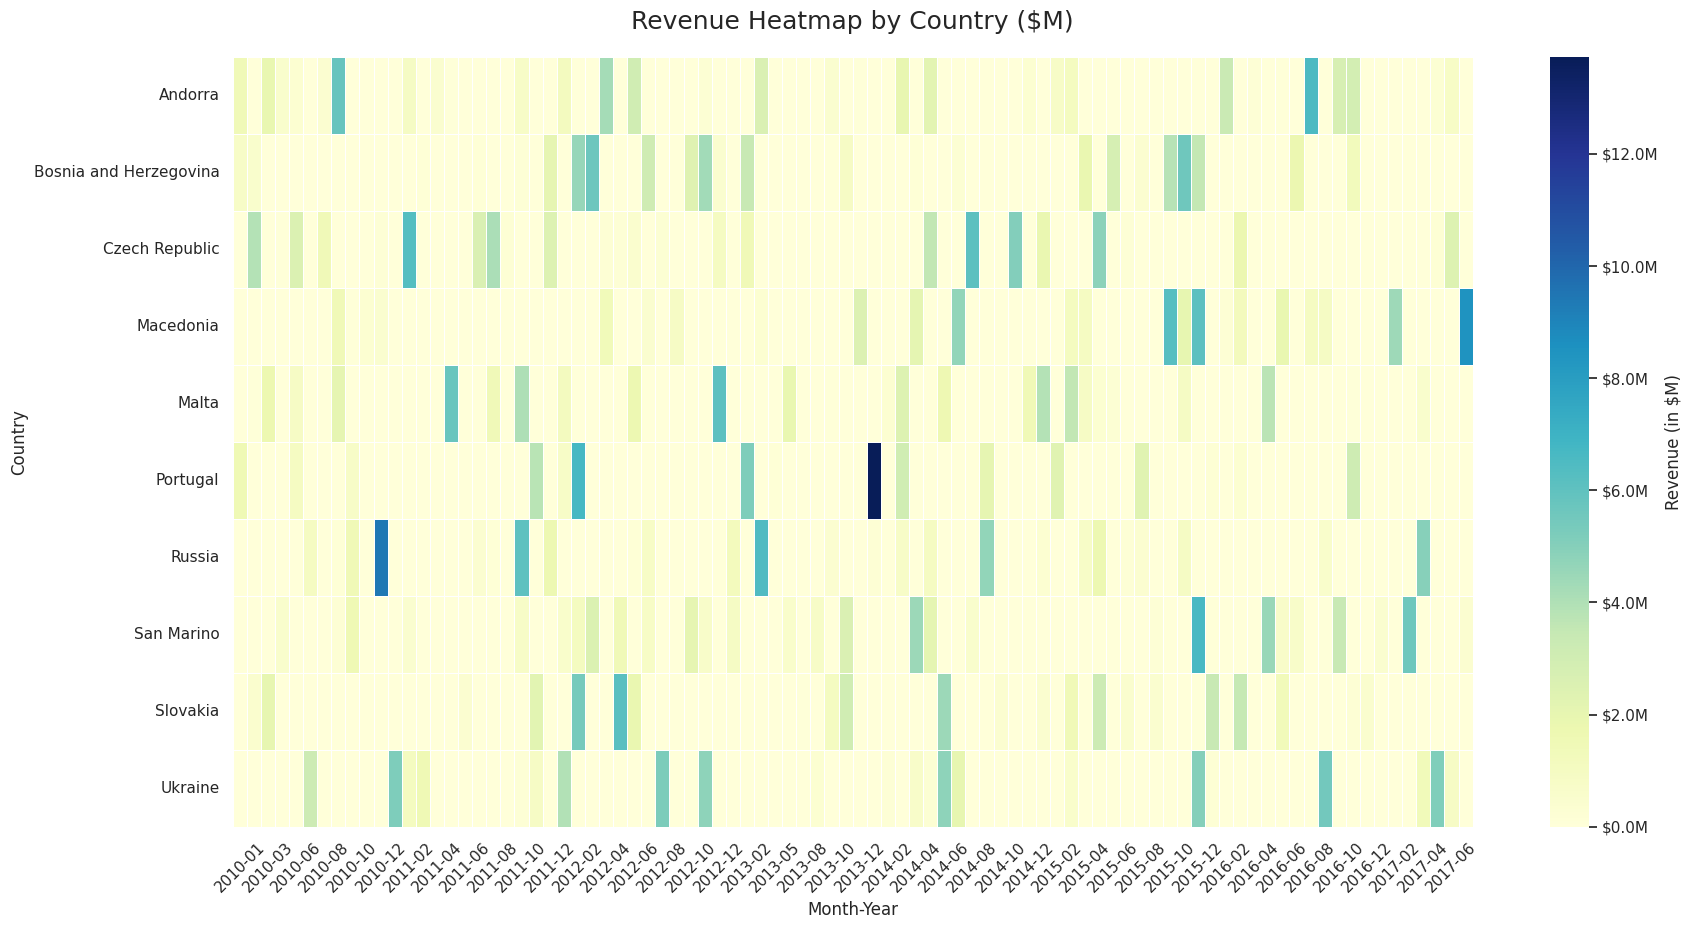

In [30]:
# Prepare matrix (ensure unknown is removed)
pivot_df = df_heatmap[df_heatmap['country_name'] != 'unknown'].pivot_table(
    index='country_name',
    columns='month_year',
    values='revenue',
    aggfunc='sum',
    fill_value=0)

# Draw Heatmap
plt.figure(figsize=(20, 10))

# Configure color scale via cbar_kws
ax = sns.heatmap(pivot_df,
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={
                'label': 'Revenue (in $M)',
                'format': ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')})
plt.title('Revenue Heatmap by Country ($M)', fontsize=18, pad=20)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Geographic Revenue Dynamics Analysis**

The heatmap revealed key patterns that were hidden in the line charts:


*   Project-based sales: revenues have a "spotty" structure, indicating work with large one-time contracts rather than stable monthly demand.
*   Critical drivers (Anomalies): Portugal (end of 2013) stands out with record revenue exceeding $13M in a single month, as well as a spike in Russia (end of 2010). These individual transactions formed a significant share of the period's profit.
*   Market stability: Ukraine and the Czech Republic show the most regular orders. Despite smaller amounts, these countries provide predictable cash flow.
*   Global pauses: periods were identified (e.g., mid-2013) when activity dropped simultaneously across all markets, suggesting the influence of external factors.


### 3. Sales Dynamics by Product Category

To better understand the profit structure, the revenue dynamics were analyzed by product category across the entire observation period. Using a heatmap allows moving away from cluttered line charts and clearly identifying which product groups form the financial backbone of the company, and which have seasonal or episodic sales patterns. Each cell in the chart represents the total revenue of a specific category for a given month.

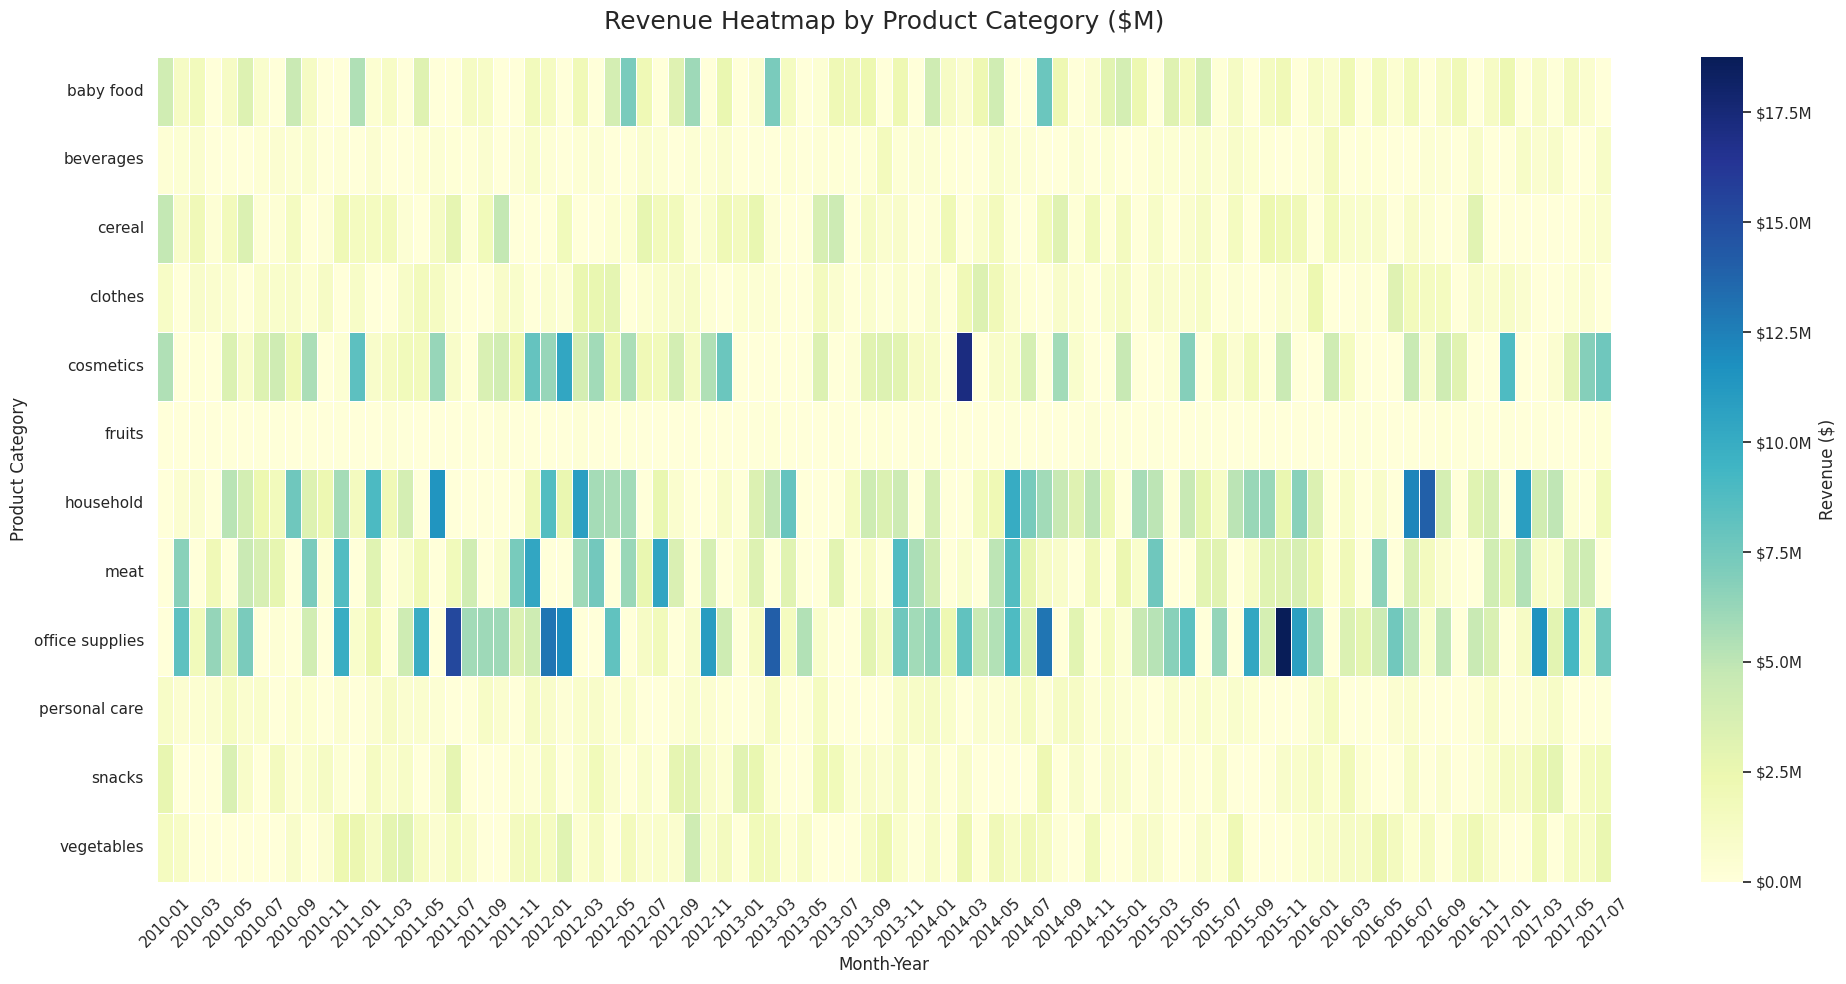

In [31]:
# Prepare matrix: Category vs Month
category_pivot = sales.pivot_table(
    index='item_type',
    columns=sales['order_date'].dt.to_period('M').astype(str),
    values='revenue',
    aggfunc='sum',
    fill_value=0)

# Visualization
plt.figure(figsize=(20, 10))

sns.heatmap(category_pivot,
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={
                'label': 'Revenue ($)',
                'format': ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')})

plt.title('Revenue Heatmap by Product Category ($M)', fontsize=18, pad=20)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Revenue Dynamics Analysis by Product Category**


*   Stable revenue drivers: Household, Office Supplies, and Cosmetics show the most consistently intense coloring throughout the period. These are the key segments providing regular cash flow.

*   Absence of narrow specialization: the map shows the company successfully sells a wide range of goods — from food products to industrial goods. This diversification reduces risks when demand falls in any one segment.

*   Low seasonal dependency: most categories do not have clearly marked "empty" months, indicating well-established distribution chains operating regardless of the season.









## Weekly Cyclicity and Seasonal Sales Analysis

In this section, we examine the company's rhythm: how sales are distributed within the week and throughout the calendar year. This reveals hidden patterns and identifies products with a pronounced calendar dependency.

### 1. Product Sales Analysis by Day of Week

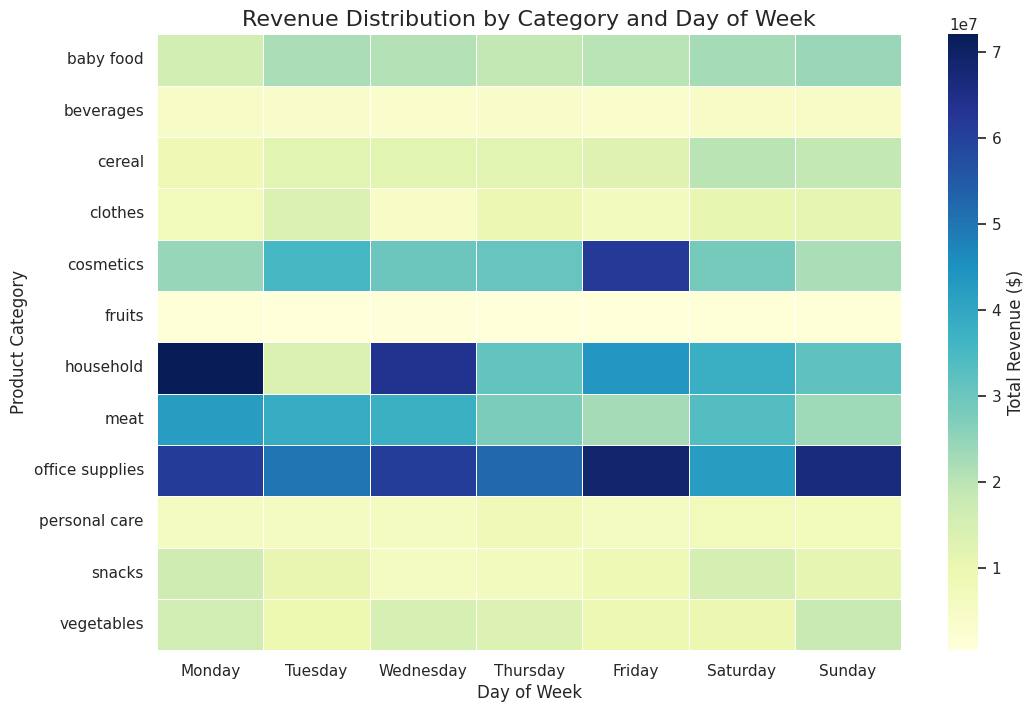

In [32]:
# Add day of week name
sales['day_of_week'] = sales['order_date'].dt.day_name()

# Order days of week chronologically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create matrix: Category vs Day of Week
weekday_pivot = sales.pivot_table(
    index='item_type',
    columns='day_of_week',
    values='revenue',
    aggfunc='sum'
).reindex(columns=days_order)

# Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(weekday_pivot, cmap="YlGnBu", annot=False, linewidths=.5,
            cbar_kws={'label': 'Total Revenue ($)'})

plt.title('Revenue Distribution by Category and Day of Week', fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Product Category')
plt.show()

### 2. Product Seasonality

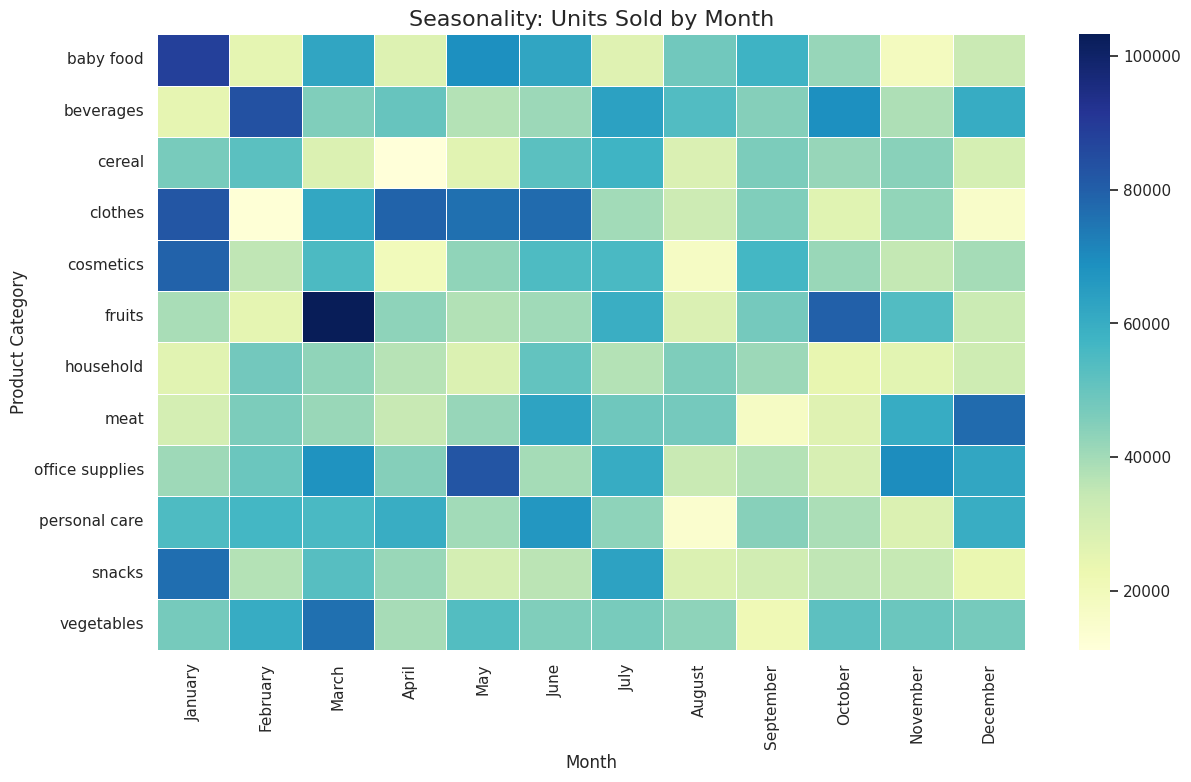

In [33]:
# Add month name
sales['month'] = sales['order_date'].dt.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

# Seasonality matrix
seasonality_pivot = sales.pivot_table(
    index='item_type',
    columns='month',
    values='units_sold',
    aggfunc='sum'
).reindex(columns=months_order)

# Visualization
plt.figure(figsize=(14, 8))
sns.heatmap(seasonality_pivot, cmap="YlGnBu", linewidths=.5)
plt.title('Seasonality: Units Sold by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Product Category')
plt.show()

**Cyclicity and Seasonality Analysis Results**


**1. Weekly Cycles**


*   Evenness: most categories (e.g., Meat, Cereal, Personal Care) show stable revenue throughout the week. This indicates no specific peak days and the need for even staffing load.
*   Peak days: on the heatmap, the Household category shows highest activity on Monday and Wednesday, while Cosmetics and Office Supplies show spikes on Friday.

**2. Seasonal Fluctuations**


*   Pronounced seasonality: the Fruits category shows anomalous peaks in March and October, likely linked to regional harvest cycles. Clothes and Baby Food demonstrate high activity at the start of the year (January–May), which may indicate large procurement volumes at the beginning of new seasons.

*   Stable groups: Vegetables and Household remain relatively stable throughout the year, serving as a reliable base for overall sales volume.
*   Logistics planning: identified low demand in certain categories during summer months (e.g., Baby Food in August) allows planning warehouse maintenance or assortment rotation without losing critical profit.


The business has a mixed model: stable daily sales of basic goods combined with pronounced seasonal spikes in food product groups.